**Chapter 11 – Training Deep Neural Networks**

_This notebook contains all the sample code and solutions to the exercises in chapter 11._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-mlp/blob/main/11_training_deep_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-mlp/blob/main/11_training_deep_neural_networks.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.10 or above:

In [3]:
import sys

assert sys.version_info >= (3, 10)

Are we using Colab or Kaggle?

In [4]:
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

If using Colab, the TorchMetrics library is not pre-installed so we must install it manually:

In [5]:
if IS_COLAB:
    %pip install -q torchmetrics

We also need PyTorch ≥ 2.6.0:

In [6]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

This chapter can be very slow without a hardware accelerator, so if we can find one, let's use it:

In [7]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

Let's issue a warning if there's no hardware accelerator available:

In [8]:
if device == "cpu":
    print("Neural nets can be very slow without a hardware accelerator.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [9]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Vanishing/Exploding Gradients Problem

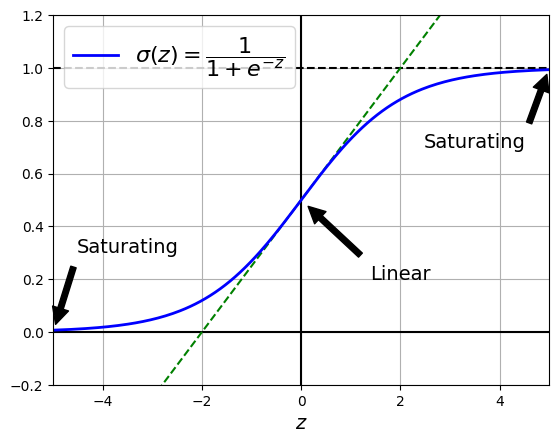

In [10]:
# extra code – this cell generates Figure 11–1

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

plt.show()

## Glorot and He Initialization

So, unfortunately for legacy reasons PyTorch initialises the `nn.Linear` module's weights using Kaiming uniform initialisation except with the weights scaled down by a factor of $\sqrt{6}$, as well as initialising the bias terms randomly. 

This weight inititalisation is not optimal for any common activation function 😞, and the initialisation of the biases has no added value.

One solution is to multiply the weights (found at `layer.weight.data`) by $\sqrt{6}$ ($6^{\frac{1}{2}}$) and zero out the biases to get the proper Kaiming initialisation (ideal for `ReLU` and variations).

In [11]:
import torch
import torch.nn as nn

layer = nn.Linear(40, 10)
print(layer.weight.data[0])
print(layer.bias.data)
print()

layer.weight.data *= 6 ** 0.5  # Kaiming init (or 3 ** 0.5 for LeCun init)
torch.zero_(layer.bias.data)
print(layer.weight.data[0])
print(layer.bias.data)

tensor([-0.1262, -0.1454,  0.0442, -0.0362,  0.1049,  0.0841,  0.0223, -0.0060,
        -0.0961, -0.1278, -0.0247,  0.1383, -0.0462,  0.0014,  0.0514, -0.1130,
        -0.1114,  0.0349, -0.0413, -0.0559, -0.1014, -0.1120, -0.0780,  0.0702,
         0.1452,  0.0799, -0.0216, -0.0424, -0.1097, -0.0015,  0.1411, -0.0496,
         0.1139,  0.0427, -0.0761,  0.1193, -0.0314,  0.1301,  0.1230, -0.0377])
tensor([-0.0540,  0.0887, -0.1210,  0.0913,  0.1201,  0.0266, -0.0715,  0.1225,
         0.0170, -0.1123])

tensor([-0.3091, -0.3562,  0.1082, -0.0887,  0.2570,  0.2059,  0.0546, -0.0148,
        -0.2354, -0.3129, -0.0606,  0.3389, -0.1130,  0.0034,  0.1259, -0.2768,
        -0.2728,  0.0854, -0.1012, -0.1368, -0.2485, -0.2743, -0.1911,  0.1719,
         0.3556,  0.1957, -0.0529, -0.1038, -0.2688, -0.0036,  0.3456, -0.1215,
         0.2790,  0.1045, -0.1864,  0.2923, -0.0769,  0.3187,  0.3013, -0.0923])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


But this initialisation method is clearer and less error-prone:

In [12]:
layer = nn.Linear(40, 10)
nn.init.kaiming_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

One simple option of guaranteeing the entire model submodel hierarchy for all Linear layers:

In [13]:
def use_he_init(module):
    print(module.__class__.__name__)
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

model = nn.Sequential(nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1), nn.ReLU())
model.apply(use_he_init) # <- this is how you apply it to all the matching layers

Linear
ReLU
Linear
ReLU
Sequential


Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=1, bias=True)
  (3): ReLU()
)

In [14]:
model = nn.Sequential(nn.Linear(50, 40), nn.LeakyReLU(negative_slope=0.2))
model.apply(use_he_init)

Linear
LeakyReLU
Sequential


Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
)

Interesting (and less common) intitialisation function with applications in Recurrent Neural Networks and Generative Adviserial Networks:

In [15]:
from torch.nn.init import orthogonal_


## Better Activation Functions

### Leaky ReLU

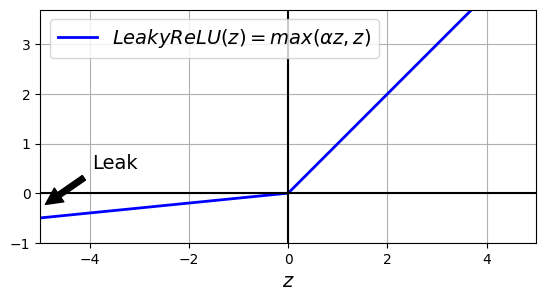

In [16]:
# extra code – this cell generates Figure 11–2

def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

**Summary of ReLU variations:**

Leaky ReLU (`nn.LeakyReLU(alpha)`) avoids the *dying ReLUs problem* by having a slop for $z < 0$. The hyperparameter $\alpha$ (Where $LeakyReLU_{\alpha} = max(\alpha z, z$) defines how much the function leaks, where having a slope for $z < 0$ ensures the function cannot ever "die" but instead "goes into a coma" it can more easily recover from eventually.

<br>
Per 2015 paper by Bing Xu et al. it was found that:

- *Leaky ReLU* always outperformed strict ReLU activation function
    - Setting a huge leak of $\alpha = 0.2$ seemed to result in better performance than small leaks like $\alpha = 0.01$.

- *Randomized leaky ReLU (RReLU)* -- where $\alpha$ is picked randomly in a given range during training and is fixed to an average value during testing -- performed fairly well, seeming to act as a **regularizer, reducing the risk of overfitting**.

- *Parametric leaky ReLU (PReLU)* -- where $\alpha$ is authorized to be learned during training (parameter modified by backpropagation) -- was reported to strongly outperform ReLU on large image datasets, but overfit on smaller datasets.

All of these are to be **combined with Kaiming initialisation**, but we reduce the variance due to the negative slope: we **scale it down** by a factor of $1 + \alpha^{2}$

**Main downside ReLU family activation functions**: they're non-smooth causing a discontinuity in their derivatives, which makes gradient descent jump around more and slows down convergence.

In [17]:
nn.ReLU() # <- default one

nn.LeakyReLU(
    negative_slope=0.1 # alpha
)

nn.RReLU(
    lower=1/8, # range start
    upper=1/3 # range end ... for random value picking during training (averaged during inference)
)

nn.PReLU(
    num_parameters=1, # <- a learned parameter (during training)
    init=0.25, # <- initial value
    device=device # <- since it's a learned parameter
)

# We combine all of these with Kaiming initialisation where we
# scale down the variance by a factor of 1 + alpha^2 :
alpha = 0.2
model = nn.Sequential(nn.Linear(50, 40), nn.LeakyReLU(negative_slope=alpha))
# see: p.336 HOMLP
nn.init.kaiming_uniform_(
    model[0].weight,
    a=alpha, # <- the alpha value to use
    nonlinearity="leaky_relu" # <- controls the scaling for leaky variations
)
nn.init.kaiming_normal_(
    model[0].weight,
    a=alpha, # <- see above
    nonlinearity="leaky_relu" # <- see above
)

Parameter containing:
tensor([[ 0.0909,  0.0500, -0.1707,  ...,  0.1047, -0.0663, -0.1329],
        [ 0.3798,  0.0925, -0.3933,  ...,  0.0400,  0.2810, -0.0339],
        [-0.1114,  0.0478, -0.1691,  ...,  0.3351, -0.1379,  0.1496],
        ...,
        [ 0.1853, -0.0472, -0.0528,  ..., -0.0503, -0.3911,  0.3720],
        [ 0.3792,  0.1082, -0.1661,  ...,  0.0263,  0.2503, -0.2143],
        [-0.1304, -0.3768, -0.2794,  ...,  0.0730,  0.0189,  0.1235]],
       requires_grad=True)

In [18]:
torch.manual_seed(42)
alpha = 0.2
model = nn.Sequential(nn.Linear(50, 40), nn.LeakyReLU(negative_slope=alpha))
nn.init.kaiming_uniform_(model[0].weight, alpha, nonlinearity="leaky_relu")
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

### ELU

Implementing ELU in PyTorch is trivial, just add an `ELU` layer after each `Linear` layer in your model, and make sure to use Kaiming initialization for these `Linear` layers:

In [19]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 40), nn.ELU())
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

- **Main upside ELU:** faster convergence rate during training
- **Main downside ELU:** slower to compute due to the exponential ($ELU_{\alpha}(z) = \alpha(e^{z} - 1) \text{ if } z < 0 \text{ else } z$), so slower at inference time.
- To be combined with Kaiming initialisation (as above)

### SELU

By default, the SELU hyperparameters (`scale` and `alpha`) are tuned in such a way that the mean output of each neuron remains close to 0, and the standard deviation remains close to 1 (assuming the inputs are standardized with mean 0 and standard deviation 1 too, and other constraints are respected, as explained in the book). Using this activation function, even a 1,000 layer deep neural network preserves roughly mean 0 and standard deviation 1 across all layers, avoiding the exploding/vanishing gradients problem:

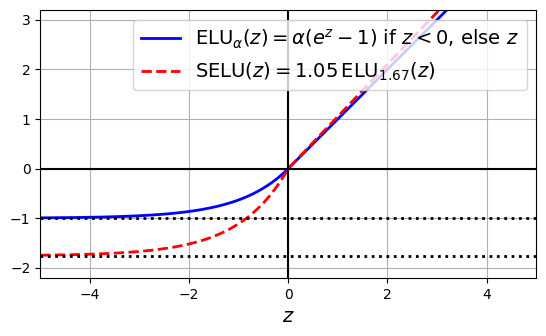

In [20]:
# extra code – this cell generates Figure 11–3

from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
# (see equation 14 in the paper):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

**SELU use-cases:**

MLPs (as in pure dense layer neural networks) benefit from SELU due to SELU self-normalising MLPs by making the output of each layer preserve a norm of 0 and a standard deviation of 1 during training, solving the unstable/exploding/vanishing gradients problem. So SELU activation functions may outperform ELU for plain MLPs (especially deep ones).

Conditions for it to actually work:
- Input features must be standardised: $\mu=0$ and $\sigma=1$.
- Every hidden layer's weights must be initialised using LeCun normal initialisation.
- Self-normalising property is only guaranteed with plain MLPs (e.g. not RNNs or networks with skip connections like Wide & Deep ones, where it will probably not outperform ELU)
- ⚠️ **You cannot use other regularisation techniques such as $\ell_{1}$ or $\ell_{2}$ regularization, batch-norm, layer-norm, max-norm, or regular dropout.**

Using SELU is straightforward:

In [21]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 40), nn.SELU())
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

### GELU, Swish, SwiGLU, Mish, and ReLU²

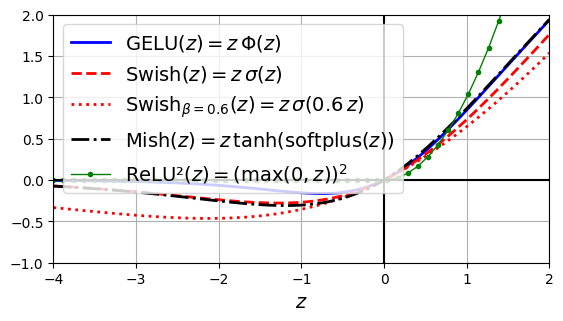

In [22]:
# extra code – this cell generates Figure 11–4

def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

def relu_squared(z):
    return np.maximum(0, z)**2

z = np.linspace(-4, 2, 50)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "k-.", linewidth=2,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot(z, relu_squared(z), "g.-", linewidth=1,
         label=fr"ReLU²$(z) = (\max(0, z))^2$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

plt.show()

**Notes on Activation Functions & implementation details**

1. **GELU(z) = $z\Phi(z)$:** in practice **outperforms all the aforementioned activation functions**, but is **computationally more expensive** and the performance boost it provides is not always sufficient to justify the extra cost.

   **Implementation Notes:**

   Per definition $\Phi$ is an integral that can be written in terms of $\text{erf}(z)$ -- the Gauss error function -- which is still an integral. What is done in practice is that $\text{erf}$ is usually approximated polynomially & piece-wise **by HARDWARE**, among other strategies like lookup tables. So the full integral of $\Phi$ or $\text{erf}$ is not being "solved" here, but the approximation of $\text{erf}$ is still computationally expensive nonetheless.

   High-level language implementations focus on re-creating the shape of $z\Phi(z)$:
  
   - $\text{GELU}(z)$ is for example "approximately equal to" $z\sigma(1.702z)$ (with $\sigma$ the sigmoid function: $\sigma(z) = \frac{1}{1 + e^{-z}}$), which is cheap and used in many Transformers, but not very accurate.

   - A more accurate approximation of $z\Phi(z)$ is $\text{GELU}_{\text{tanh}}(z) = 0.5z(1 + \tanh(\sqrt{\frac{2}{\pi}}(z + 0.044715z^3)))$ (Hendrycks & Gimpel), but also immediately more computationally expensive.

   Hardware-wise, `erf` is typically implemented:

   - **CPU (libm):** using piecewise polynomial or rational approximations, Chebyshev expansions and range reduction, where accuracy guarantees are specified. 

   - **GPU (CUDA, ROCm):** Polynomial approximations that are possibly table-assisted, mainly tuned for throughput over perfect precision

   - **Accelerators (TPU, etc.):** often low-degree polynomial approximations, possibly fused into activation kernels. 

2. **$\text{Swish}(z) = z\sigma(z)$ aka SiLU (or Generalised Swish with a tweakable hyperparameter $\beta$: $\text{Swish}_{\beta}(z) = z\sigma(\beta z)$):** may outperform GELU and other activation functions.

   You can tune $\beta$ like any hyperparameter or even make it trainable (letting gradient descent optimise it). You can use one $\beta$ for the entire model or one $\beta_{i}$ per layer $i$ to keep the model efficient and avoid overfitting. 

3. **$\text{SwiGLU}(\textbf{z}) = \text{Swish}_{\beta}(\textbf{z}) \otimes \text{Linear}(\textbf{z})$** (where $\otimes$ here means "item-wise multiplication" and not tensor/Kronecker product): is a popular Swish variant where the inputs go through the Swish activation function AND in parallel through a linear layer, then both outputs are multiplied itemwise.

   This is often implemented by doubling the output dimensions of the previous linear layer, then splitting the outputs in two along the feature dimension to get $\textbf{z}_{1}$ and $\textbf{z}_{2}$, and finally applying $\text{Swish}_{\beta}(\textbf{z}_{1}) \otimes \textbf{z}_{2}$.

   This is a variant of the **gated linear unit (GLU)**.

   The itemwise multiplication gives the model more expressive power, allowing it to learn when to turn off (= multiply by 0) or amplify specific features -- this is called a **gating mechanism**.

   **SwiGLU is very common in modern transformers**.

4. **$\text{mish}(z) = z\tanh(\text{softplus}(z))$ (where $\text{softplus}(z)=\log(1 + \exp(z))$)**  may outperform other activation functions including ones like Swish and GELU by a tiny margin.

   Mish overlaps almost perfectly with Swish when $z$ is negative, and almost perfectly with GELU when $z$ is positive.

5. **$\text{ReLU}^2(z) = max(0, z)^2$:** has all the qualities of ReLU (simplicity, computational efficiency, sparse output, no saturation on the positive side) but it also has smooth gradients at $z = 0$. 

   **Often outperforms other activation functions**, especially for **sparse models**.

   But: **training can be less stable** due to **increased sensitivity to outliers** and **dying ReLUs**.

---

**🤔 What to use "generally"?**

- ReLU is a good default for *most tasks*.
- Swish is probably a better default for *complex tasks*, possibly with learnable $\beta$ for the *most complex tasks*.
- Mish and SwiGLU may give you *slightly better results at the cost of better compute*.
- If you care about *latency*: leaky ReLU or parametrized leaky ReLU for complex tasks; $\text{ReLU}^2$ especially for *sparse models*. 

**SwiGLU**

So to implement this one:

1. we're doubling the previous `Linear` layer's output dimension
2. and then use `z1, z2 = z.chunk(2, dim=0-1)` to split its output in two
3. and compute `F.silu(beta * z1) * z2` (this is the result, matching the formula $\text{SwiGLU}(\textbf{z}) = \text{Swish}_{\beta}(\textbf{z}) \otimes \text{Linear}(\textbf{z})$, noting that Swish == SiLU, and $\text{Swish}_{\beta}$ is just Swish multiplying the input to the sigmoid function in its definition by $\beta$) 

In [23]:
import torch.nn.functional as F

class SwiGLU(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta

    def forward(self, x):
        z1, z2 = x.chunk(2, dim=-1) # <- 2. we split the output in two

        #return F.silu(self.beta * z1) * z2  (<- 3a. alternative implementation!)

        param_swish = z1 * torch.sigmoid(self.beta * z1) # <- 3b. this right here is the definition of Swish_{\beta}
        return param_swish * z2 # <- 4. <- this right here is the definition of SwiGLU


torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(50, 2 * 40), # <- 1. doubling the previous Linear layer's output dimension.
    SwiGLU(beta=0.2)
)
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

**ReLU<sup>2</sup>**

For this one we just implement our own ReLU module (`ReLU2`) where we use `F.relu(input).square()` because that's what it is

In [24]:
import torch.nn.functional as F

class ReLU2(nn.Module):
    def forward(self, x):
        return F.relu(x).square()

torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 40), ReLU2())
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

### 🗒️ NOTE: Simpliefied approximated implementations of common activation functions implemented in PyTorch

Are available in PyTorch and their names start with `Hard` such as `nn.Hardsigmoid`, `nn.Hardtanh`, `nn.Hardswish`. 

Their use-case is for devices where you want to minimise computational complexity such as on mobile devices.

### General conclusion

While using carefully designed initialisation can help minimise the danger of unstable graidents **at the beginning of training**, it doesn't guaratnee that they won't come back *during* training.

## Batch Normalization

^ technique of adding the **"batch normalisation" operation** just **before** OR **after** the activation function of each hidden layer.

> The batch normalisation operation **zero-centers and normalises each input**, and then **scales and and shifts** the result **using two new (learned by backprop) parameter vectors** per layer: one for scaling and the other for shifting. The operation lets the model learn the optimal scale and mean of each of the layer's inputs.
> 
> In many cases, if you add a BN layer as the **very first** layer of your neural network, **you do not need to standardize your training set** -- the BN layer will do it for you (approximately because it only looks at one batch at a time and it can also rescale and shift each input feature).


In order to zero-center and normalize the inputs, the algorithm needs to estimate each input's mean and standard deviation. It does so by evaluating the mean and standard deviation of the input over the current mini-batch. See p.376 of HOMLP for the algorithm.

Because the mean and standard deviation are *computed independently per batch* during training, there's nothing to immediately use in the normalisation algorithm in their place during inference.

Due to this these operations not only learn the **scale** and **shift** parameters (these purely by backprop), but the BatchNorm layer will also "learn" or track an **exponential moving average** for the vector of **means** and **variances** when evaluating each batch. These estimated means and variances are used in the equations (p.376) during `model.eval()` time/at inference time.

So in total this operation has 4 "learned" parameters:
- **scale** and **shift** (learned by backprop)
- **mean** and **variance** (computed by exponential moving average during training)

**✅ Benefits of Batch Norm:**

- Vanishing gradients problem strongly reduced to the point of being able to use saturating activation functions such as tanh and sigmoid.
- Networks are much less sensitive to the weight initialisation
- Ability to use larger learning rates to significantly speed up learning process
- It acts as a regulariser, reducing need for other regularisation techniques

**❌ Drawbacks of Batch Norm:**

- Adds some complexity to the model
- \*A runtime penalty of extra computation at *inference time*
  
  \* however this can be mitigated by updating the weights and biases of the previous layer with those of the scale and shift parameters one time, avoiding the penalty. P.377


Training with BatchNorm will be slower, but convergence will happen in less steps, and wall time will be shorter.

With the BN layers **after** the activation functions:

In [25]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(1 * 28 * 28), # <- used as the first layer (removing the need for scaling the inputs)
    nn.Linear(1 * 28 * 28, 300), # <- out: 300
    nn.ReLU(),
    nn.BatchNorm1d(300), # <- matches the out: 300 ^
    nn.Linear(300, 100), # <- out: 100
    nn.ReLU(),
    nn.BatchNorm1d(100), # <- matches the out 100 ^
    nn.Linear(100, 10)
)

In [26]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

In [27]:
dict(model[1].named_buffers()).keys()

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])

After we train this batchnorm'ed model, we need to ensure we toggle on inference mode with `.eval()` or the whole batch norm mean + variance computation logic will stay in place and continue being updated (undesireably)

Quite often, applying BN before the activation function works better. Moreover, the `Linear` layer before a `BatchNorm1d` layer does not need to have bias terms, since the `BatchNorm1d` layer has some as well. So you can set `bias=False` when creating those layers:

In [28]:
torch.manual_seed(42)

# because we don't start with a BatchNorm1d layer, we have to normalise our training set before we use them during training
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 300, bias=False),
    nn.BatchNorm1d(300),
    nn.ReLU(),
    nn.Linear(300, 100, bias=False),
    nn.BatchNorm1d(
        100,
        momentum=0.1 # <- this default is good for large batch sizes, but not so much for small batch sizes of 32-64! (see below)
    ),
    nn.ReLU(),
    nn.Linear(100, 10)
)

`BatchNorm1d` has some hyperparameters. Most defaults are usually fine, however you may want to tweak the `momentum` (used in computing the exponential moving averages or the mean and the variance) hyperparameter based on your batch sizes. A good momentum is close to `0`. 

Values closer to `0.1` are good for large batch sizes, but not great for small batch sizes such as `32` or `64`.

---
Batch norm is one of the most used layers in deep neural networks, especially **deep convolutional neural networks** (where BN layers are regularly omitted in architecture diagrams due to their assumed presence). 

**Issues with Batch Normalisation:**
- The computed **statistics for an instance are biased by the other samples in a batch**, which may reduce performance (especially for **small batches**)
- BN also **struggles with some architectures like recurrent neural networks**

This is why BN is more and more replaced with Layer Normalisation. 

⚠️ **HOWEVER** layer normalisation only applies in specific contexts/architecutres and is more of a computational enablement/scaling mechanism for e.g. Transformers than something with statistical meaning like BN!!


## Layer Normalization

Instead of normalizing across the batch dimensions, LN normalizes across the feature dimensions.

Unlike BN, LN can compute the required statistics on the fly, at each time step, independently for each instance. This also means that it behaves the same way during training and testing (unlike BN), and it does not need to use exponential moving averages to estimate the feature statistics across all instances in the training set like BN does. 

The idea really is that given an input flat feature vector like `[0.1284, 0.1808, 0.6414, 0.8151, 0.8046, 0.2788, 0.1656, 0.477]`, we compute FOR THAT SINGULAR INSTANCE:

$\textbf{x}_{0} = [0.1284, 0.1808, 0.6414, 0.8151, 0.8046, 0.2788, 0.1656, 0.477]$

$\mu_{0} = \text{mean}([0.1284, 0.1808, ..., 0.477]) = \text{mean}(\textbf{x})$

$\sigma_{0}^2 = \text{var}(\textbf{x})$

And then normalise **every element in the row** (so $x_{0, 1} = 0.1284$, $x_{0, 2} = 0.1808$, ...) as follows: 

$x'_{0, j} = \frac{x_{0, j} - \mu_{0}}{\sqrt{\sigma_{0}^2 + \varepsilon}}$

And then we apply the usual **shift** ($\boldsymbol{\beta}$) and **scale** ($\boldsymbol{\gamma}$) vectors (which are learned parameters as before):

$\textbf{z}_{0} = \boldsymbol{\gamma} \otimes \textbf{x}_{0}' + \boldsymbol{\beta}$

The above then occurs for all $\textbf{x}_{i}$ for $i = 0,1,2, ..., n$ with $n$ the total number of instances in the train set. 



LN lerans a **scale** and an **offset** parameter for each input feature, just like BN.

In [29]:
torch.manual_seed(42)

inputs = torch.randn(32, 3, 100, 200)  # a batch of random RGB images
layer_norm = nn.LayerNorm([100, 200]) # <- normalises over the the "number of colour channels (3)".
result = layer_norm(inputs)  # normalizes over the last two dimensions

In [30]:
means = inputs.mean(dim=[2, 3], keepdim=True)
vars_ = inputs.var(dim=[2, 3], keepdim=True, unbiased=False)
stds = torch.sqrt(vars_ + layer_norm.eps)
result2 = layer_norm.weight * (inputs - means) / stds + layer_norm.bias
assert torch.allclose(result, result2)

To normalize over **all channels at once** (don't break it op per colour channel):

In [31]:
layer_norm = nn.LayerNorm([3, 100, 200]) # <- to normalize over all channels at once (don't break it op per colour channel)
result = layer_norm(inputs)  # normalizes over the last three dimensions

## Gradient Clipping

Primarily applicable to recurrent neural networks where using batch norm is tricky.

See the line `nn.utils.clip_grad_norm_(...)` in the training function in the next section.

# Reusing Pretrained Layers

## Transfer Learning with PyTorch

Let's split the fashion MNIST training set in two:
* `X_train_A`: all images of all items except for T-shirts/tops and pullovers (classes 0 and 2).
* `X_train_B`: a much smaller training set of just the first 20 images of T-shirts/tops and pullovers.

The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using `Linear` layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image, as we will see in the chapter 12).

Let's fetch the Fashion MNIST data and split it into datasets A and B:

In [32]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
X = torch.FloatTensor(fashion_mnist.data.reshape(-1, 1, 28, 28) / 255.)
y = torch.from_numpy(fashion_mnist.target.astype(int))
in_B = (y == 0) | (y == 2)  # Pullover or T-shirt/top
X_A, y_A = X[~in_B], y[~in_B]
y_A = torch.maximum(y_A - 2, torch.tensor(0))  # [1,3,4,5,6,7,8,9] => [0,..,7]
X_B, y_B = X[in_B], (y[in_B] == 2).to(dtype=torch.float32).view(-1, 1)

train_set_A = TensorDataset(X_A[:-7_000], y_A[:-7_000])
valid_set_A = TensorDataset(X_A[-7_000:-5_000], y_A[-7_000:-5_000])
test_set_A = TensorDataset(X_A[-5_000:], y_A[-5_000:])
train_set_B = TensorDataset(X_B[:20], y_B[:20])
valid_set_B = TensorDataset(X_B[20:5_000], y_B[20:5_000])
test_set_B = TensorDataset(X_B[5_000:], y_B[5_000:])

train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_set_A, batch_size=32)
test_loader_A = DataLoader(test_set_A, batch_size=32)
train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_set_B, batch_size=32)
test_loader_B = DataLoader(test_set_B, batch_size=32)

In [33]:
len(train_loader_B.dataset) # Has just 20 items

20

In [34]:
len(valid_loader_B.dataset) # has 5k - 20 items

4980

Let's define the `evaluate_tm()` and `train()` functions, much like in Chapter 10:

In [35]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            # Uncomment to activate gradient clipping:
            #nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

Let's define our first model for task A:

In [36]:
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 8)
)
model_A = model_A.to(device)

In [37]:
model_A.apply(use_he_init) # <- this initialises all the layers using Kaiming HE initialisation (since we use ReLU as the activation function)

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=8, bias=True)
)

In [38]:
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005)
xentropy = nn.CrossEntropyLoss() # <- CrossEntropyLoss since we have a multiclass problem
accuracy = torchmetrics.Accuracy(
    # the multiclass problem:
    task="multiclass",
    num_classes=8
).to(device)
history_A = train(
    model_A,
    optimizer,
    xentropy,
    accuracy,
    train_loader_A,
    valid_loader_A,
    n_epochs
)

Epoch 1/20, train loss: 0.6338, train metric: 0.7954, valid metric: 0.8290
Epoch 2/20, train loss: 0.3494, train metric: 0.8801, valid metric: 0.8850
Epoch 3/20, train loss: 0.3046, train metric: 0.8948, valid metric: 0.8960
Epoch 4/20, train loss: 0.2804, train metric: 0.9023, valid metric: 0.8110
Epoch 5/20, train loss: 0.2650, train metric: 0.9071, valid metric: 0.8875
Epoch 6/20, train loss: 0.2517, train metric: 0.9118, valid metric: 0.8945
Epoch 7/20, train loss: 0.2405, train metric: 0.9157, valid metric: 0.8825
Epoch 8/20, train loss: 0.2322, train metric: 0.9189, valid metric: 0.9020
Epoch 9/20, train loss: 0.2245, train metric: 0.9218, valid metric: 0.9100
Epoch 10/20, train loss: 0.2157, train metric: 0.9248, valid metric: 0.9025
Epoch 11/20, train loss: 0.2107, train metric: 0.9273, valid metric: 0.8960
Epoch 12/20, train loss: 0.2048, train metric: 0.9279, valid metric: 0.8940
Epoch 13/20, train loss: 0.2002, train metric: 0.9298, valid metric: 0.9190
Epoch 14/20, train lo

So, we got a pretty good accuracy score on the validation set ^

In [39]:
torch.manual_seed(40)

# so then the new model that has to classify in binary the two clothing pieces we removed from model A:
model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
).to(device)

In [40]:
model_B.apply(use_he_init) # <- this initialises all the layers using Kaiming HE initialisation (since we use ReLU as the activation function)

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=1, bias=True)
)

In [41]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B.parameters(), lr=0.005) # <- standard Stochastic Gradient Descent as usual
xentropy = nn.BCEWithLogitsLoss() # <- binary classification specific, see 10_neural_nets_with_pytorch.ipynb
accuracy = torchmetrics.Accuracy(
    task="binary" # <- in this case we have a binary task
).to(device)
history_B = train(
    model_B,
    optimizer,
    xentropy,
    accuracy,
    train_loader_B, # <- just 20 items
    valid_loader_B, # <- 5k - 20 items
    n_epochs
)

Epoch 1/20, train loss: 0.7365, train metric: 0.5000, valid metric: 0.5120
Epoch 2/20, train loss: 0.7062, train metric: 0.5000, valid metric: 0.5412
Epoch 3/20, train loss: 0.6789, train metric: 0.5500, valid metric: 0.5737
Epoch 4/20, train loss: 0.6544, train metric: 0.6000, valid metric: 0.6056
Epoch 5/20, train loss: 0.6328, train metric: 0.6500, valid metric: 0.6343
Epoch 6/20, train loss: 0.6143, train metric: 0.7500, valid metric: 0.6624
Epoch 7/20, train loss: 0.5971, train metric: 0.7500, valid metric: 0.6867
Epoch 8/20, train loss: 0.5808, train metric: 0.7500, valid metric: 0.7080
Epoch 9/20, train loss: 0.5653, train metric: 0.7500, valid metric: 0.7303
Epoch 10/20, train loss: 0.5497, train metric: 0.7500, valid metric: 0.7474
Epoch 11/20, train loss: 0.5356, train metric: 0.7500, valid metric: 0.7614
Epoch 12/20, train loss: 0.5224, train metric: 0.8000, valid metric: 0.7767
Epoch 13/20, train loss: 0.5096, train metric: 0.8000, valid metric: 0.7896
Epoch 14/20, train lo

In [42]:
evaluate_tm(model_B, test_loader_B, accuracy)

tensor(0.8514, device='cuda:0')

So now we'll try stealing model A's weights and adding our own final output layer. The reused layers can still be tweaked by gradient descent in this case (they're not locked):

In [43]:
import copy

torch.manual_seed(40)
reused_layers = copy.deepcopy(model_A[:-1]) # <- deepcopy to not touch the others
model_B_on_A = nn.Sequential(
    *reused_layers, # <- expansion param of a "list" object
    nn.Linear(100, 1)  # new output layer for task B (it's a binary classifier so there's a single output)
).to(device)

model_B_on_A

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=1, bias=True)
)

So because the new output layer was initialised randomly, it will make large errors (at least during the first few epochs). So there would be huge error gradients that wreck the reused weights.

One approach to avoid this is to freeze the reused layers during the first few epochs, giving the new layer some time to learn reasonable weights:

In [44]:
for layer in model_B_on_A[:-1]:
    for param in layer.parameters():
        param.requires_grad = False

So we froze the layers and then we can just train JUST the last new randomly-initialised layer for the first e.g. 10 epochs:

In [45]:
n_epochs = 10 # <- **FIRST FEW EPOCHS**
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss() # <- same as above attempt (obviously)
accuracy = torchmetrics.Accuracy(task="binary").to(device) # <- same as above attempt (obvs)
history_B = train(
    model_B_on_A,
    optimizer,
    xentropy,
    accuracy,
    train_loader_B,
    valid_loader_B,
    n_epochs
)

Epoch 1/10, train loss: 0.5370, train metric: 0.9000, valid metric: 0.8651
Epoch 2/10, train loss: 0.5246, train metric: 0.9500, valid metric: 0.8819
Epoch 3/10, train loss: 0.5129, train metric: 0.9500, valid metric: 0.8936
Epoch 4/10, train loss: 0.5019, train metric: 0.9500, valid metric: 0.9000
Epoch 5/10, train loss: 0.4914, train metric: 0.9500, valid metric: 0.9054
Epoch 6/10, train loss: 0.4815, train metric: 0.9500, valid metric: 0.9110
Epoch 7/10, train loss: 0.4720, train metric: 0.9500, valid metric: 0.9143
Epoch 8/10, train loss: 0.4629, train metric: 0.9500, valid metric: 0.9165
Epoch 9/10, train loss: 0.4542, train metric: 0.9500, valid metric: 0.9201
Epoch 10/10, train loss: 0.4459, train metric: 0.9500, valid metric: 0.9225


And then of course we unfreeze the layers:

In [46]:
for layer in model_B_on_A[2:]:
    for param in layer.parameters():
        param.requires_grad = True

And continue training, where now **all weights** can get tweaked by gradient descent:

In [47]:
n_epochs = 20 # <- 20 extra epochs on top of the first 10 ones
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(
    model_B_on_A,
    optimizer,
    xentropy,
    accuracy,
    train_loader_B,
    valid_loader_B,
    n_epochs
)

Epoch 1/20, train loss: 0.4379, train metric: 0.9500, valid metric: 0.9241
Epoch 2/20, train loss: 0.4284, train metric: 0.9500, valid metric: 0.9251
Epoch 3/20, train loss: 0.4193, train metric: 0.9500, valid metric: 0.9261
Epoch 4/20, train loss: 0.4107, train metric: 0.9500, valid metric: 0.9279
Epoch 5/20, train loss: 0.4024, train metric: 1.0000, valid metric: 0.9285
Epoch 6/20, train loss: 0.3945, train metric: 1.0000, valid metric: 0.9293
Epoch 7/20, train loss: 0.3869, train metric: 1.0000, valid metric: 0.9301
Epoch 8/20, train loss: 0.3797, train metric: 1.0000, valid metric: 0.9303
Epoch 9/20, train loss: 0.3727, train metric: 1.0000, valid metric: 0.9311
Epoch 10/20, train loss: 0.3661, train metric: 1.0000, valid metric: 0.9309
Epoch 11/20, train loss: 0.3597, train metric: 1.0000, valid metric: 0.9317
Epoch 12/20, train loss: 0.3535, train metric: 1.0000, valid metric: 0.9331
Epoch 13/20, train loss: 0.3476, train metric: 1.0000, valid metric: 0.9329
Epoch 14/20, train lo

In [48]:
print(len(train_loader_B.dataset)) # <- we still used the VERY SMALL small dataset here..
print(len(valid_loader_B.dataset)) # <- only this one is large

20
4980


So, what's the final verdict?

In [49]:
evaluate_tm(model_B_on_A, test_loader_B, accuracy)

tensor(0.9378, device='cuda:0')

(I messed around with the seed and got it to be better that way, without messing with the seed we had it slightly better at `0.05` or so. But I guess that's a seed problem.)

# Faster Optimizers

So, we have 5 ways to speed up training:

1. Applying a good initialisation strategy for the connection weights
2. Using a good activation function
3. Using Batch-Norm or Layer-norm
4. Reusing parts of a pretained network (auxiliary task or unsupervised learning)
5. Choosing an optimiser different from the regular gradient descent optimizer (<- this section)

In [50]:
# extra code – a little function to test an optimizer on Fashion MNIST

train_set = TensorDataset(X[:55_000], y[:55_000])
valid_set = TensorDataset(X[55_000:60_000], y[55_000:60_000])
test_set = TensorDataset(X[60_000:], y[60_000:])

def build_model(seed=42):
    torch.manual_seed(seed)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 10)
    ).to(device)
    model.apply(use_he_init)
    return model

def test_optimizer(model, optimizer, n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    history = train(model, optimizer, xentropy, accuracy.to(device),
                    train_loader, valid_loader, n_epochs)
    return history, evaluate_tm(model, test_loader, accuracy)

In [51]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
history_sgd, acc_sgd = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.5659, train metric: 0.7959, valid metric: 0.8402
Epoch 2/10, train loss: 0.4048, train metric: 0.8513, valid metric: 0.8470
Epoch 3/10, train loss: 0.3652, train metric: 0.8661, valid metric: 0.8578
Epoch 4/10, train loss: 0.3404, train metric: 0.8749, valid metric: 0.8714
Epoch 5/10, train loss: 0.3197, train metric: 0.8822, valid metric: 0.8780
Epoch 6/10, train loss: 0.3062, train metric: 0.8855, valid metric: 0.8658
Epoch 7/10, train loss: 0.2922, train metric: 0.8907, valid metric: 0.8760
Epoch 8/10, train loss: 0.2828, train metric: 0.8943, valid metric: 0.8718
Epoch 9/10, train loss: 0.2725, train metric: 0.8981, valid metric: 0.8770
Epoch 10/10, train loss: 0.2633, train metric: 0.9019, valid metric: 0.8684


## Momentum optimization

So for momentum we just set the parameter `momentum` of the `torch.optim.SGD` optimizer. The standard value is 0.9 and it will almost always go faster than regular gradient descent!

> Take the pure stochasatic gradient descent weight update:
>
> $\bm{\theta} \leftarrow \bm{\theta} - \eta\nabla_{\bm{\theta}}J(\bm{\theta})$
>

Pure momentum optimisation looks like this when updating the weights while gaining a momentum in a specific direction, especially when continued alongside the exact same direction:


$\textbf{m} \leftarrow \beta\textbf{m} - \eta\nabla_{\bm{\theta}}J(\bm{\theta})$ (kind of an exponential moving average type of approach, the momentum vector $\textbf{m}$ is initially just all-$0$)

With $\beta$ the *momenthum coefficient* ("friction") $\in [0, 1]$ ($0$ = high friction, $1$ = no friction; to avoid overshooting)

Followed by the actual gradient descent update:

$\bm{\theta} \leftarrow \bm{\theta} + \textbf{m}$

In [52]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(
    model.parameters(),
    momentum=0.9, # <- momentum optimizer!
    lr=0.05
)
history_momentum, acc_momentum = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.6054, train metric: 0.7809, valid metric: 0.7974
Epoch 2/10, train loss: 0.4714, train metric: 0.8322, valid metric: 0.8356
Epoch 3/10, train loss: 0.4352, train metric: 0.8455, valid metric: 0.8370
Epoch 4/10, train loss: 0.4107, train metric: 0.8518, valid metric: 0.8422
Epoch 5/10, train loss: 0.3933, train metric: 0.8587, valid metric: 0.8582
Epoch 6/10, train loss: 0.3889, train metric: 0.8605, valid metric: 0.8616
Epoch 7/10, train loss: 0.3770, train metric: 0.8630, valid metric: 0.8522
Epoch 8/10, train loss: 0.3729, train metric: 0.8668, valid metric: 0.8604
Epoch 9/10, train loss: 0.3603, train metric: 0.8697, valid metric: 0.8678
Epoch 10/10, train loss: 0.3470, train metric: 0.8753, valid metric: 0.8590


## Nesterov Accelerated Gradient

This is the variant that looks in the direction of the the momentum before computing the gradient vector on that direction, which often ends up closer to the optimum, allowing for faster convergence.

$\textbf{m} \leftarrow \beta\textbf{m} - \eta\nabla_{\bm{\theta}}J(\bm{\theta} + \beta \textbf{m})$ (argument to the error function $J$ here is further ahead along the direction of the momentum than normal momentum)

$\bm{\theta} \leftarrow \bm{\theta} + \textbf{m}$

In [53]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(
    model.parameters(),
    momentum=0.9, # <- we still enable momentum
    nesterov=True, # <- we just toggle the way it is computed to be the look-ahead method
    lr=0.05
)
history_nesterov, acc_nesterov = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.5447, train metric: 0.8021, valid metric: 0.7748
Epoch 2/10, train loss: 0.4410, train metric: 0.8415, valid metric: 0.8542
Epoch 3/10, train loss: 0.4140, train metric: 0.8505, valid metric: 0.8430
Epoch 4/10, train loss: 0.3912, train metric: 0.8609, valid metric: 0.8528
Epoch 5/10, train loss: 0.3719, train metric: 0.8673, valid metric: 0.8656
Epoch 6/10, train loss: 0.3677, train metric: 0.8700, valid metric: 0.8612
Epoch 7/10, train loss: 0.3595, train metric: 0.8717, valid metric: 0.8524
Epoch 8/10, train loss: 0.3472, train metric: 0.8764, valid metric: 0.8694
Epoch 9/10, train loss: 0.3467, train metric: 0.8749, valid metric: 0.8592
Epoch 10/10, train loss: 0.3336, train metric: 0.8811, valid metric: 0.8662


And in this case we do see a faster convergence than the normal momentum alternative!

## AdaGrad

$\textbf{s} \leftarrow \textbf{s} + \nabla_{\bm{\theta}}J(\bm{\theta}) \otimes \nabla_{\bm{\theta}}J(\bm{\theta})$

$\bm{\theta} \leftarrow \bm{\theta} - \eta\nabla_{\bm{\theta}}J(\bm{\theta}) \oslash \sqrt{\textbf{s} + \varepsilon}$

(With $\otimes$ = element-wise multiplication and $\oslash$ = element-wise division)


Is:
- An example of **adaptive learning rate**
- Helps point the resulting gradient updates more directly towards global optimum (by scaling down gradient vector along steepest dimensions)
- Requires much less tuning of the learning rate hyperparamter $\eta$

However:
- ✅ **Good for:** simple quadratic problems
- ❌ **Bad for:** training deep Neural Networks (tends to stop too early, getting slowed down too mucb before reaching the global optimum)

⚠️ **Consequently:** don't use for Deep NNs (but it may be efficient for simpler tasks like linear regression)

In [54]:
model = build_model()  # extra code
optimizer = torch.optim.Adagrad( # <- this is the optimiser itself. **Don't use for Deep NNs!!!!** consider for linear regression
    model.parameters(),
    lr=0.0009 # <- (I changed this to match RMSProp becase the original high value of 0.05 there made it diverge for w/e reason)
)
history_adagrad, acc_adagrad = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.7030, train metric: 0.7705, valid metric: 0.8134
Epoch 2/10, train loss: 0.5294, train metric: 0.8215, valid metric: 0.8262
Epoch 3/10, train loss: 0.4913, train metric: 0.8329, valid metric: 0.8322
Epoch 4/10, train loss: 0.4704, train metric: 0.8409, valid metric: 0.8344
Epoch 5/10, train loss: 0.4564, train metric: 0.8444, valid metric: 0.8350
Epoch 6/10, train loss: 0.4460, train metric: 0.8480, valid metric: 0.8392
Epoch 7/10, train loss: 0.4371, train metric: 0.8506, valid metric: 0.8422
Epoch 8/10, train loss: 0.4302, train metric: 0.8525, valid metric: 0.8428
Epoch 9/10, train loss: 0.4241, train metric: 0.8542, valid metric: 0.8490
Epoch 10/10, train loss: 0.4191, train metric: 0.8568, valid metric: 0.8488


## RMSProp

**Avoids slowing down too fast** (as in AdaGrad above) by **accumulating only the gradients from the most recent iterations** -- as opposed to all the gradients since the beginning of training -- by using exponential decay in the first step:

$\textbf{s} \leftarrow \alpha\textbf{s} + (1-\alpha)\nabla_{\mathbf{\theta}}J(\mathbf{\theta}) \otimes \nabla_{\mathbf{\theta}}J(\mathbf{\theta})$

$\bm{\theta} \leftarrow \bm{\theta} - \eta\nabla_{\bm{\theta}}J(\bm{\theta}) \oslash \sqrt{\textbf{s} + \varepsilon}$

With the decay rate $\alpha$ typically set to $0.9$ (this is a new hyperparameter, but the default value of $0.9$ often works well, so you may not need to tune it at all)

- In theory, this one requires much less tuning of the learning hyperparameter $\eta$ too (like AdaGrad above)
- Except for very simple problems, this almost always outperforms AdaGrad.
- Was the most preferred optimization algorithm of many researchers before Adam optimization came around (below)

In [55]:
model = build_model()  # extra code
optimizer = torch.optim.RMSprop( # <- this one has its own module to use
    model.parameters(),
    alpha=0.9, # <- default value, see above
    lr=0.0009 # <- (I messed around with it because it was diverging at the original 0.05)
)
history_rmsprop, acc_rmsprop = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.5201, train metric: 0.8121, valid metric: 0.8564
Epoch 2/10, train loss: 0.3917, train metric: 0.8580, valid metric: 0.8588
Epoch 3/10, train loss: 0.3662, train metric: 0.8689, valid metric: 0.8614
Epoch 4/10, train loss: 0.3584, train metric: 0.8732, valid metric: 0.8648
Epoch 5/10, train loss: 0.3541, train metric: 0.8761, valid metric: 0.8684
Epoch 6/10, train loss: 0.3544, train metric: 0.8788, valid metric: 0.8620
Epoch 7/10, train loss: 0.3510, train metric: 0.8785, valid metric: 0.8754
Epoch 8/10, train loss: 0.3482, train metric: 0.8808, valid metric: 0.8724
Epoch 9/10, train loss: 0.3530, train metric: 0.8818, valid metric: 0.8508
Epoch 10/10, train loss: 0.3541, train metric: 0.8816, valid metric: 0.8612


## Adam Optimization

**"Adaptive Momentum Estimation"** combines the ideas of both momentum optimization and RMSProp:

1. It keeps track of an exponentially decaying average of past gradients
2. It keeps track of an exponentially decaying average of past squared graidents

Defined as follows:

$\textbf{m} \leftarrow \beta_{1}\textbf{m} - (1-\beta_{1})\nabla_{\mathbf{\theta}}J(\mathbf{\theta})$

$\textbf{s} \leftarrow \beta_{2}\textbf{s} + (1-\beta_{2})\nabla_{\mathbf{\theta}}J(\mathbf{\theta}) \otimes \nabla_{\mathbf{\theta}}J(\mathbf{\theta})$

$\hat{\textbf{m}} \leftarrow \frac{\textbf{m}}{1 - \beta_{1}^{t}}$ (This step is an "implementation detail" to boost $\textbf{m}$ and $\textbf{s}$ since they are initialsed at 0 and will be biased towards 0 at the beginning, this boosts them")

$\hat{\textbf{s}} \leftarrow \frac{\textbf{s}}{1 - \beta_{2}^{t}}$ (See above ^)

$\bm{\theta} \leftarrow \bm{\theta} + \eta\hat{\textbf{m}} \oslash \sqrt{\hat{\textbf{s}} + \varepsilon}$

Where $t$ represents the iteration number starting at $1$.

With $\beta_{1}$ usually initialised to $0.9$ and $\beta_{2}$ usually initialised to $0.999$. The smoothing term $\varepsilon$ avoids divisition by $0$ and is intialised to a tiny number such as $10^{-8}$

**✅ Benefits:**
- You don't have to tune the learning rate $\eta$ as much as non-adaptive learning rate algorithms, and can often use the default value of $\eta=0.001$

In [56]:
model = build_model()  # extra code
optimizer = torch.optim.Adam(model.parameters(), betas=(
    0.9, # <- beta_{1}
    0.999 # <- beta_{2}
), lr=0.001)
history_adam, acc_adam = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.4999, train metric: 0.8219, valid metric: 0.8232
Epoch 2/10, train loss: 0.3774, train metric: 0.8619, valid metric: 0.8644
Epoch 3/10, train loss: 0.3415, train metric: 0.8744, valid metric: 0.8498
Epoch 4/10, train loss: 0.3161, train metric: 0.8828, valid metric: 0.8736
Epoch 5/10, train loss: 0.2993, train metric: 0.8881, valid metric: 0.8768
Epoch 6/10, train loss: 0.2859, train metric: 0.8927, valid metric: 0.8776
Epoch 7/10, train loss: 0.2719, train metric: 0.8991, valid metric: 0.8700
Epoch 8/10, train loss: 0.2632, train metric: 0.9008, valid metric: 0.8750
Epoch 9/10, train loss: 0.2551, train metric: 0.9030, valid metric: 0.8868
Epoch 10/10, train loss: 0.2438, train metric: 0.9083, valid metric: 0.8868


**Adamax Optimization**

"Just one more optimizer you can try if you experience problems with Adam" depending on your exact dataset. (It's a variation on top of it)

In [57]:
model = build_model()  # extra code
optimizer = torch.optim.Adamax(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_adamax, acc_adamax = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.7050, train metric: 0.7639, valid metric: 0.7782
Epoch 2/10, train loss: 0.5110, train metric: 0.8159, valid metric: 0.8322
Epoch 3/10, train loss: 0.4707, train metric: 0.8355, valid metric: 0.8474
Epoch 4/10, train loss: 0.4412, train metric: 0.8431, valid metric: 0.8524
Epoch 5/10, train loss: 0.4239, train metric: 0.8515, valid metric: 0.8568
Epoch 6/10, train loss: 0.4150, train metric: 0.8556, valid metric: 0.8594
Epoch 7/10, train loss: 0.4029, train metric: 0.8580, valid metric: 0.8554
Epoch 8/10, train loss: 0.3963, train metric: 0.8612, valid metric: 0.8550
Epoch 9/10, train loss: 0.3906, train metric: 0.8625, valid metric: 0.8570
Epoch 10/10, train loss: 0.3919, train metric: 0.8638, valid metric: 0.8460


**Nadam Optimization**

"Adam + Nesterov trick" that sometimes outperforms Adam and RMSProp, sometimes not, depending on the task.

In [58]:
model = build_model()  # extra code
optimizer = torch.optim.NAdam(model.parameters(), betas=(0.9, 0.999), lr=0.001)
history_nadam, acc_nadam = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.4907, train metric: 0.8230, valid metric: 0.8574
Epoch 2/10, train loss: 0.3624, train metric: 0.8665, valid metric: 0.8658
Epoch 3/10, train loss: 0.3284, train metric: 0.8784, valid metric: 0.8622
Epoch 4/10, train loss: 0.3049, train metric: 0.8873, valid metric: 0.8834
Epoch 5/10, train loss: 0.2875, train metric: 0.8928, valid metric: 0.8782
Epoch 6/10, train loss: 0.2754, train metric: 0.8967, valid metric: 0.8822
Epoch 7/10, train loss: 0.2619, train metric: 0.9011, valid metric: 0.8678
Epoch 8/10, train loss: 0.2528, train metric: 0.9047, valid metric: 0.8778
Epoch 9/10, train loss: 0.2441, train metric: 0.9069, valid metric: 0.8820
Epoch 10/10, train loss: 0.2372, train metric: 0.9107, valid metric: 0.8880


**AdamW Optimization**

"Adam plus Weight Decay (but properly done)" - where Weight Decay is a *regularisation technique* on the *weights* that aims to keep them small (therefore reducing the *exploding gradients problem* and contributing to a higher chance of convergence into a minimum).

In [59]:
model = build_model()  # extra code
optimizer = torch.optim.AdamW(
    model.parameters(),
    betas=(0.9, 0.999),
    weight_decay=1e-5, # <- we probably want to tune this when we use AdamW.
    lr=0.001
)
history_adamw, acc_adamw = test_optimizer(model, optimizer)  # extra code

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.4999, train metric: 0.8219, valid metric: 0.8232
Epoch 2/10, train loss: 0.3774, train metric: 0.8619, valid metric: 0.8644
Epoch 3/10, train loss: 0.3415, train metric: 0.8744, valid metric: 0.8498
Epoch 4/10, train loss: 0.3161, train metric: 0.8828, valid metric: 0.8736
Epoch 5/10, train loss: 0.2993, train metric: 0.8881, valid metric: 0.8768
Epoch 6/10, train loss: 0.2859, train metric: 0.8927, valid metric: 0.8776
Epoch 7/10, train loss: 0.2719, train metric: 0.8991, valid metric: 0.8700
Epoch 8/10, train loss: 0.2632, train metric: 0.9008, valid metric: 0.8750
Epoch 9/10, train loss: 0.2551, train metric: 0.9030, valid metric: 0.8868
Epoch 10/10, train loss: 0.2438, train metric: 0.9083, valid metric: 0.8868


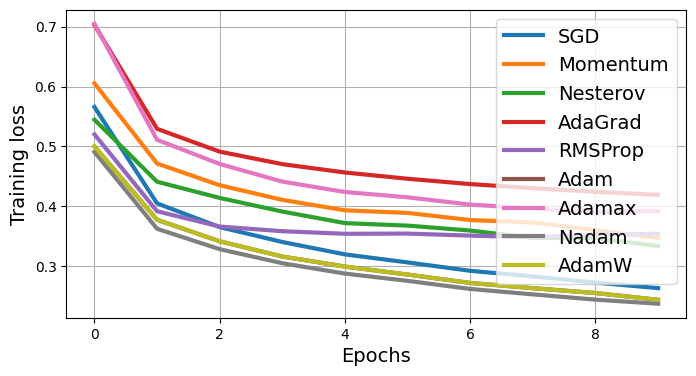

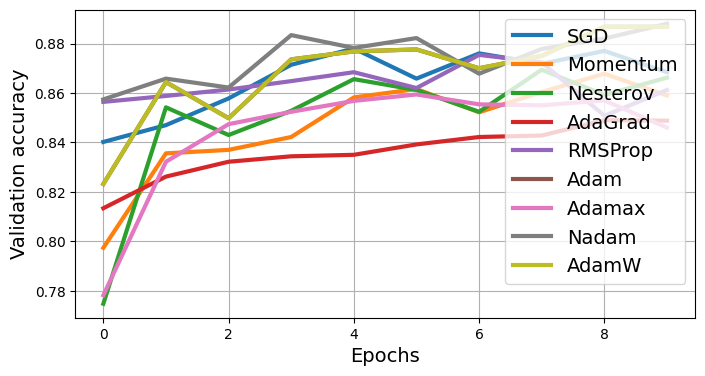

In [61]:
# extra code – visualize the learning curves of all the optimizers

for plot in ("train_losses", "valid_metrics"):
    plt.figure(figsize=(8, 4))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip(
        (history_sgd, history_momentum, history_nesterov, history_adagrad,
         history_rmsprop, history_adam, history_adamax, history_nadam,
         history_adamw), opt_names.split()):
        plt.plot(history[plot], label=opt_name, linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"train_losses": "Training loss", "valid_metrics": "Validation accuracy"}[plot])
    plt.legend(loc="upper right")
    plt.show()

## Optimizers based on Hessians

It is generally not possible to compute the Hessians (2nd order partial derivatives) versus the Jacobians (1st order partial derivatives) as Jacobians result in $n$ results per output ($n$ the number of parameters) and Hessians in $n^2$ results per output. The computation of the Hessians results in algorithms that do not fit in memory. Computing the Hessian matrix is also generally just too slow.

However we can use stochastic methhods to approximate second-order information. Shampoo is an example of an algorithm that accumulated gradient information to approximate the second-order terms (like how Adam accumulates first-order stats):


In [59]:
from torch_optimizer import Shampoo

model = build_model()
optimizer = Shampoo(model.parameters(), lr=0.1, momentum=0, weight_decay=0, epsilon=0.0001, update_freq=1)
history_shampoo, acc_shampoo = test_optimizer(model, optimizer)

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


Epoch 1/10, train loss: 0.5337, train metric: 0.8123, valid metric: 0.8402


KeyboardInterrupt: 

# Learning Rate Scheduling

In [ ]:
def train_with_scheduler(model, optimizer, loss_fn, metric, train_loader,
                         valid_loader, n_epochs, scheduler):# -> dict[str, list[Any]]:# -> dict[str, list[Any]]:
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        losses = []
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_metric) # <- we add the scheduler to the training loop!!!
        else:
            scheduler.step() # <- we add the scheduler to the training loop!!!
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

def test_scheduler(model, optimizer, scheduler, n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train_with_scheduler(
        model, optimizer, xentropy, metric, train_loader, valid_loader,
        n_epochs, scheduler)
    return history, evaluate_tm(model, test_loader, metric)

### Exponential Scheduling

Learning rate is multiplied by a constant factor gamma at a some regular intervar like "every epoch". 

The factor `gamma` is another hyperparameter that you can tune.
Generally it should be $\in [0, 1]$ and close to $1$, like $0.9$ to avoid decreasing the learning rate too fast.

In [63]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
exp_scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer, # <- optimizer is given as an argument!!!
    gamma=0.9 # <- new hyperparameter
)

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


In [64]:
history_exp, acc_exp = test_scheduler(model, optimizer, exp_scheduler)  # extra code

Epoch 1/10, train loss: 0.5659, train metric: 0.7959, valid metric: 0.8402
Learning rate: 0.04500
Epoch 2/10, train loss: 0.4001, train metric: 0.8535, valid metric: 0.8506
Learning rate: 0.04050
Epoch 3/10, train loss: 0.3577, train metric: 0.8686, valid metric: 0.8588
Learning rate: 0.03645
Epoch 4/10, train loss: 0.3319, train metric: 0.8785, valid metric: 0.8756
Learning rate: 0.03281
Epoch 5/10, train loss: 0.3112, train metric: 0.8857, valid metric: 0.8754
Learning rate: 0.02952
Epoch 6/10, train loss: 0.2964, train metric: 0.8904, valid metric: 0.8682
Learning rate: 0.02657
Epoch 7/10, train loss: 0.2825, train metric: 0.8945, valid metric: 0.8800
Learning rate: 0.02391
Epoch 8/10, train loss: 0.2709, train metric: 0.8991, valid metric: 0.8760
Learning rate: 0.02152
Epoch 9/10, train loss: 0.2605, train metric: 0.9027, valid metric: 0.8808
Learning rate: 0.01937
Epoch 10/10, train loss: 0.2505, train metric: 0.9073, valid metric: 0.8814
Learning rate: 0.01743


In [65]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1)

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


In [66]:
history_perf, acc_perf = test_scheduler(model, optimizer, perf_scheduler)  # extra code

Epoch 1/10, train loss: 0.5659, train metric: 0.7959, valid metric: 0.8402
Learning rate: 0.05000
Epoch 2/10, train loss: 0.4048, train metric: 0.8513, valid metric: 0.8470
Learning rate: 0.05000
Epoch 3/10, train loss: 0.3652, train metric: 0.8661, valid metric: 0.8578
Learning rate: 0.05000
Epoch 4/10, train loss: 0.3404, train metric: 0.8749, valid metric: 0.8714
Learning rate: 0.05000
Epoch 5/10, train loss: 0.3197, train metric: 0.8822, valid metric: 0.8780
Learning rate: 0.05000
Epoch 6/10, train loss: 0.3062, train metric: 0.8855, valid metric: 0.8658
Learning rate: 0.05000
Epoch 7/10, train loss: 0.2922, train metric: 0.8907, valid metric: 0.8760
Learning rate: 0.05000
Epoch 8/10, train loss: 0.2828, train metric: 0.8943, valid metric: 0.8718
Learning rate: 0.00500
Epoch 9/10, train loss: 0.2368, train metric: 0.9121, valid metric: 0.8860
Learning rate: 0.00500
Epoch 10/10, train loss: 0.2294, train metric: 0.9151, valid metric: 0.8866
Learning rate: 0.00500


### Cosine Annealing

Follows the formula of:

$\eta_{t} = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})(1 + \cos(\frac{t}{T_{max}}\pi))$

- ✅ Generally performs better than Exponential Scheduling
- ❌ However this introduces two new hyperparameters, $T_{max}$ and $n_{min}$, where it is not easy to know in advance how many epochs to train for and when to stop decreasing the learning rate to fill into this formula.

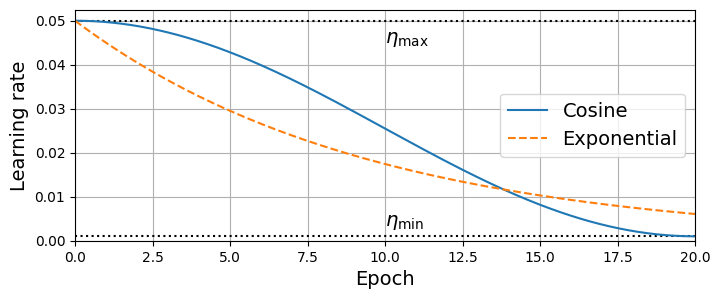

In [67]:
t = np.linspace(0, 20, 400)
eta_min = 0.001
eta_max = 0.05
t2 = 20
eta_cos_t = eta_min + 0.5 * (eta_max - eta_min) * (1 + np.cos(t / t2 * np.pi))
eta_exp_t = 0.9 ** t * eta_max

plt.figure(figsize=(8, 3))
plt.hlines([eta_min, eta_max], 0, 20, color="k", linestyle="dotted")
plt.plot(t, eta_cos_t, label="Cosine")
plt.plot(t, eta_exp_t, "--", label="Exponential")
plt.legend(loc="center right")
plt.text(10, eta_min + 0.0025, r"$\eta_\text{min}$")
plt.text(10, eta_max - 0.005, r"$\eta_\text{max}$")
plt.axis([0, 20, 0, eta_max * 1.05])
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.show()

In [68]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=0.001)

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


### Warmup Scheduling

One idea is to manage your warmup yourself. You first have a warmup period where you start with low LR and then go up to high LR using something like a Linear Learning Rate (`LinearLR`). 

Then, once warmed up, you switch to your intended scheduler. 

In [69]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


The following scheduler is equivalent to the previous one:

In [70]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lambda epoch: (min(epoch, 3) / 3) * (1.0 - 0.1) + 0.1) # <- this is just equivalent to the one above, it re-implements the linear logic

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


And we define the normal scheduler (`scheduler`) to only kick in after `3` epochs (`if epoch >= 3:`)

In [71]:
# extra code
def train_with_warmup(model, optimizer, loss_fn, metric, train_loader,
                      valid_loader, n_epochs, warmup_scheduler, scheduler):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):

        warmup_scheduler.step()

        # extra code
        losses = []
        metric.reset()

        for X_batch, y_batch in train_loader:

            # extra code
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")

        if epoch >= 3:  # deactivate other scheduler(s) during warmup
            scheduler.step(val_metric)

        # extra code
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

def test_warmup_scheduler(model, optimizer, warmup_scheduler, scheduler,
                          n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train_with_warmup(
        model, optimizer, xentropy, metric, train_loader, valid_loader,
        n_epochs, warmup_scheduler, scheduler)
    return history, evaluate_tm(model, test_loader, metric)

In [72]:
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1)
test_warmup_scheduler(model, optimizer, warmup_scheduler, perf_scheduler,
                      n_epochs=10, batch_size=32)

Epoch 1/10, train loss: 0.6212, train metric: 0.7838, valid metric: 0.8358
Learning rate: 0.00500
Epoch 2/10, train loss: 0.4524, train metric: 0.8381, valid metric: 0.8360
Learning rate: 0.00500
Epoch 3/10, train loss: 0.4051, train metric: 0.8525, valid metric: 0.8610
Learning rate: 0.00500
Epoch 4/10, train loss: 0.3632, train metric: 0.8660, valid metric: 0.8680
Learning rate: 0.05000
Epoch 5/10, train loss: 0.3352, train metric: 0.8767, valid metric: 0.8698
Learning rate: 0.05000
Epoch 6/10, train loss: 0.3164, train metric: 0.8836, valid metric: 0.8454
Learning rate: 0.05000
Epoch 7/10, train loss: 0.3006, train metric: 0.8875, valid metric: 0.8778
Learning rate: 0.05000
Epoch 8/10, train loss: 0.2886, train metric: 0.8921, valid metric: 0.8782
Learning rate: 0.05000
Epoch 9/10, train loss: 0.2785, train metric: 0.8964, valid metric: 0.8764
Learning rate: 0.05000
Epoch 10/10, train loss: 0.2683, train metric: 0.8993, valid metric: 0.8672
Learning rate: 0.05000


({'train_losses': [np.float64(0.621235059696689),
   np.float64(0.45242572660325503),
   np.float64(0.40510589800181257),
   np.float64(0.36318030377385085),
   np.float64(0.33521684727492274),
   np.float64(0.3163733980539859),
   np.float64(0.3005958033889237),
   np.float64(0.2886058194427347),
   np.float64(0.2785195718265294),
   np.float64(0.2682551248513765)],
  'train_metrics': [0.7838363647460938,
   0.8381090760231018,
   0.8525272607803345,
   0.8659999966621399,
   0.8767454624176025,
   0.8835999965667725,
   0.8875272870063782,
   0.892090916633606,
   0.8964363932609558,
   0.899327278137207],
  'valid_metrics': [0.8357999920845032,
   0.8360000252723694,
   0.8610000014305115,
   0.8679999709129333,
   0.8697999715805054,
   0.8453999757766724,
   0.8777999877929688,
   0.8781999945640564,
   0.8763999938964844,
   0.8672000169754028]},
 tensor(0.8611, device='cuda:0'))

### Cosine Annealing with Warm Restarts

It's just a repetition of the Cosine Annealing schedule (see above) that is repeated over and over again.

This schedule allows GD to escape local optima and plateaus automatically as it regularly shoots back up. 

The authors recommend **starting with a fairly short round of coside annealing, but then doubling $T_{max}$ after each round**. This allows gradient descent to do a lot of quick explorations at the start of training, while also taking the time to properly optimize the model later during training, possibly escaping a plateau or two along the way.

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential


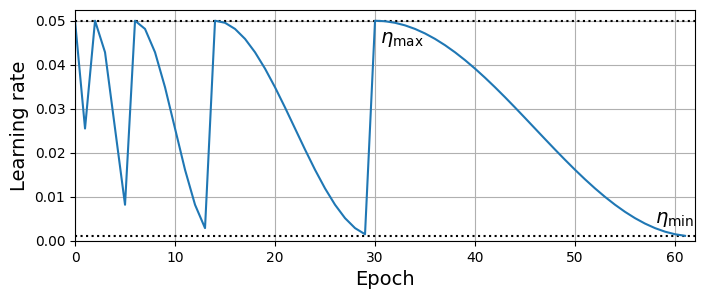

In [73]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
cosine_repeat_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=2, T_mult=2, eta_min=0.001)

lrs = []
for epoch in range(62):
    lrs.append(cosine_repeat_scheduler.get_last_lr()[0])
    cosine_repeat_scheduler.step()

plt.figure(figsize=(8, 3))
plt.hlines([eta_min, eta_max], 0, 64, color="k", linestyle="dotted")
plt.plot(lrs, label="Cosine")
plt.text(30.5, eta_max - 0.005, r"$\eta_\text{max}$")
plt.text(58, eta_min + 0.003, r"$\eta_\text{min}$")
plt.axis([0, 62, 0, eta_max * 1.05])
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.show()

Let's list all the schedulers and link to their documentation page:

In [74]:
import re

DOCS_URL = "https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler"
for name in sorted(dir(torch.optim.lr_scheduler)):
    scheduler = getattr(torch.optim.lr_scheduler, name)
    if (not name.startswith("_") and isinstance(scheduler, type) and
        issubclass(scheduler, torch.optim.lr_scheduler.LRScheduler)):
            print(f"• {DOCS_URL}.{name}.html")

• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ChainedScheduler.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ConstantLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingWarmRestarts.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CyclicLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LRScheduler.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LambdaLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.MultiStepLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.MultiplicativeLR.html
• https://pytorch.org/docs/sta

# Avoiding Overfitting Through Regularization

While **batch-norm** and **layer-norm** aren't *primarily* Regularisers (they're mainly to prevent the exploding gradients problem), they **do contribute to regularisation as well**.

## ℓ₁ and ℓ₂ regularization

### ℓ₂ regularization

For the purposes of Regularisation:

- SGD (with or w\o momentum) + $ℓ_{2}$ regularisation $=$ SGD (with or w\o momentum) + **weight decay**
- Adam + $ℓ_{2}$ regularisation $\approx$ AdamW (set the **weight decay** param) 
  - (actually AdamW is not exactly the same but performs better)

So if you want to apply $ℓ_{2}$ regularisation, just choose the corresponding weight-decay optimizer, e.g.:

In [75]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, weight_decay=1e-4)
history = test_optimizer(model, optimizer)

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/10, train loss: 0.5655, train metric: 0.7958, valid metric: 0.8380
Epoch 2/10, train loss: 0.4050, train metric: 0.8520, valid metric: 0.8490
Epoch 3/10, train loss: 0.3654, train metric: 0.8653, valid metric: 0.8578
Epoch 4/10, train loss: 0.3408, train metric: 0.8754, valid metric: 0.8726
Epoch 5/10, train loss: 0.3220, train metric: 0.8821, valid metric: 0.8774
Epoch 6/10, train loss: 0.3085, train metric: 0.8854, valid metric: 0.8716
Epoch 7/10, train loss: 0.2953, train metric: 0.8894, valid metric: 0.8750
Epoch 8/10, train loss: 0.2855, train metric: 0.8935, valid metric: 0.8674
Epoch 9/10, train loss: 0.2772, train metric: 0.8960, valid metric: 0.8798
Epoch 10/10, train loss: 0.2659, train metric: 0.9011, valid metric: 0.8712


So, by default we would have weight decay applied to every model parameter, including the bias terms and e.g. parameters of batch-norm and layer-norm. 

Generally this isn't a big deal, however this doesn't **contribute much to regularization** and it may **sometimes negatively impact teraining performance**!

One way around this is to manually compute the $ℓ_{2}$ loss over just the parameters you want to regularise (i.e. not the bias term params or the batch norm/layer norm params) and add this $ℓ_{2}$ loss to the main loss manually in the training loop:

(see also: Ridge Regression in Linear Regression)

In [76]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name
]

# with a training loop:
for epoch in range(n_epochs):
    total_loss = 0.0
    total_l2_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)

        # computing the losses:
        main_loss = loss_fn(y_pred, y_batch) # <- as usual

        # ‼️ NEW:
        l2_loss = sum(param.pow(2.0).sum() for param in params_to_regularize) # <- NEW: compute l2 loss for this batch (see also: ridge regression in linear regression)
        # this does it over all layers (one layer of weights gives us one "param" here), all weights (in each layer)

        loss = main_loss + 1e-4 * l2_loss # <- and add it to the total loss (the 1e-4 is equivalent to the alpha in ridge regression)

        total_loss += loss.item()
        total_l2_loss += l2_loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch + 1}/{n_epochs}"
          f" – l2 loss: {total_l2_loss / len(train_loader):.3f}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/3 – l2 loss: 637.364 – loss: 0.629
Epoch 2/3 – l2 loss: 646.751 – loss: 0.469
Epoch 3/3 – l2 loss: 648.852 – loss: 0.428


Alternatively, if we don't want to implement $ℓ_{2}$ ourselves, we can use *Pytorch's parameter groups* feature, where we have to pass a **list of dictionaries** to the optimiser, each with a `"params"` entry containing a list of parameters and optionally some hyperparameter key/valye pairs specific to this group of parameters (The group-specific hyperparameters take precedence over the opitmizer's global hyperparameters). 

In [77]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code

params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name
]
params_bias_and_bn = [
    param for name, param in model.named_parameters()
    if "bias" in name or "bn" in name
]
# Here we specify our own groups with customised hyperparameters per group!
optimizer = torch.optim.SGD([
    {"params": params_to_regularize, "weight_decay": 1e-4}, # <- Since we have SGD + weight decay here, we essentially have l2 regularisation, applied to just the weights.
    {"params": params_bias_and_bn, "weight_decay": 0}, # <- there's no benefit and possible downsides to using l2 regularisation on biases and bn params, so no weight decay here = no l2 regularisation
], lr=0.05)

# and then just use it as normal, no custom loss function summing needed.
for epoch in range(n_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/3 – loss: 0.565
Epoch 2/3 – loss: 0.404
Epoch 3/3 – loss: 0.364


### ℓ₁ regularization

Has to be implemented from scratch in PyTorch as there's nothing equivalent to it. So same as above with the manual l2 adding:

In [78]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name]
for epoch in range(n_epochs):
    total_loss = 0.0
    total_l1_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)

        # computing the losses:
        main_loss = loss_fn(y_pred, y_batch)

        # ‼️ NEW:
        l1_loss = sum(param.abs().sum() for param in params_to_regularize) # <- we have to implement l1 regularisation from scratch because PyTorch has no equivalence.
        # (l1 regularisaton = lasso regression for linear regression, applied to DL purposes here for every layer)

        loss = main_loss + 1e-4 * l1_loss # <- and add it as above

        total_loss += loss.item()
        total_l1_loss += l1_loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}"
          f" – l1 loss: {total_l1_loss / len(train_loader):.3f}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Flatten
Linear
ReLU
Linear
ReLU
Linear
ReLU
Linear
Sequential
Epoch 1/3 – l1 loss: 5701.701 – loss: 1.140
Epoch 2/3 – l1 loss: 5095.003 – loss: 0.920
Epoch 3/3 – l1 loss: 4546.200 – loss: 0.830


## Dropout

In [79]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(p=0.2), nn.Linear(28 * 28, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 10)
).to(device)
model.apply(use_he_init)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
history_dropout, acc_dropout = test_optimizer(model, optimizer, batch_size=32)

Flatten
Dropout
Linear
ReLU
Dropout
Linear
ReLU
Dropout
Linear
Sequential
Epoch 1/10, train loss: 0.6773, train metric: 0.7528, valid metric: 0.8348
Epoch 2/10, train loss: 0.5095, train metric: 0.8128, valid metric: 0.8460
Epoch 3/10, train loss: 0.4741, train metric: 0.8282, valid metric: 0.8568
Epoch 4/10, train loss: 0.4526, train metric: 0.8341, valid metric: 0.8580
Epoch 5/10, train loss: 0.4346, train metric: 0.8412, valid metric: 0.8566
Epoch 6/10, train loss: 0.4246, train metric: 0.8438, valid metric: 0.8706
Epoch 7/10, train loss: 0.4138, train metric: 0.8497, valid metric: 0.8680
Epoch 8/10, train loss: 0.4049, train metric: 0.8520, valid metric: 0.8694
Epoch 9/10, train loss: 0.3971, train metric: 0.8535, valid metric: 0.8712
Epoch 10/10, train loss: 0.3922, train metric: 0.8553, valid metric: 0.8738


**Note**: make sure to use `AlphaDropout` instead of `Dropout` if you want to build a self-normalizing neural net using SELU.

## Monte-Carlo (MC) Dropout

In [80]:
model.eval()
for module in model.modules():
    if isinstance(module, nn.Dropout):
        module.train()

X_new = torch.FloatTensor(fashion_mnist.data[:3].reshape(3, 1, 28, 28) / 255)
X_new = X_new.to(device)

torch.manual_seed(42)
with torch.no_grad():
    X_new_repeated = X_new.repeat_interleave(100, dim=0)
    y_logits_all = model(X_new_repeated).reshape(3, 100, 10)
    y_probas_all = torch.nn.functional.softmax(y_logits_all, dim=-1)
    y_probas = y_probas_all.mean(dim=1)

In [81]:
y_probas.round(decimals=2)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0300, 0.0000,
         0.9700],
        [0.9800, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0200, 0.0000, 0.0000,
         0.0000],
        [0.3500, 0.0500, 0.0400, 0.2800, 0.0500, 0.0000, 0.2100, 0.0000, 0.0100,
         0.0000]], device='cuda:0')

In [82]:
y_std = y_probas_all.std(dim=1)
y_std.round(decimals=2)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0400, 0.0000,
         0.0400],
        [0.0300, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0300, 0.0000, 0.0000,
         0.0000],
        [0.1500, 0.0400, 0.0300, 0.1500, 0.0700, 0.0000, 0.0800, 0.0000, 0.0100,
         0.0000]], device='cuda:0')

If you want to train a Monte Carlo Dropout model from scratch, you most likely want to create an extended class that always toggles training on like so, instead of hacking around as above:

In [83]:
class McDropout(nn.Dropout):
    def forward(self, input):
        return F.dropout(input, self.p, training=True)

And most likely you want to create a generic wrapper around the monte carlo prediction part as follows to make reuse/tweaking the sole hyperparameter `n_repeats` easier:

In [84]:
def mean_prediction(model, X, n_repeats):
    X_new_repeated = X_new.repeat_interleave(n_repeats, dim=0)
    y_logits = model(X_new_repeated)
    y_logits_all = y_logits.reshape(X.shape[0], n_repeats, *y_logits.shape[1:])
    y_probas_all = torch.nn.functional.softmax(y_logits_all, dim=-1)
    return y_probas_all.mean(dim=1)

In [100]:
with torch.no_grad():
  y_mean_pred = mean_prediction(model, X_new, 100)

y_mean_pred.round(decimals=2)

tensor([[0.0200, 0.1300, 0.1700, 0.0400, 0.0900, 0.0700, 0.1700, 0.1200, 0.1200,
         0.0900],
        [0.0500, 0.1000, 0.2300, 0.0500, 0.1300, 0.0700, 0.0800, 0.1300, 0.0600,
         0.1100],
        [0.0700, 0.1200, 0.1400, 0.0700, 0.1100, 0.1000, 0.0900, 0.1500, 0.0700,
         0.0800]], device='cuda:0')

## Max-Norm Regularization

Comstrains the weights $\textbf{w}$ of the incoming connections such that $\Vert\textbf{w}\Vert_{2} \leq r$, where $r$ is the **max-norm hyperparameter** and $\Vert \cdot \Vert_{2}$ the ℓ₂ norm.

- **Reducing** $r$ increases the amount of regularization (helps reduce overfitting)
- Max-norm regularization can also **help alleviate the unstable gradients problem** (if not using batch-norm or layer-norm)

Rather than adding a regularization loss to the overall loss function (as with ℓ₂ regularisation before!) max-norm regulariation is typically implemented by computing $\Vert\textbf{w}\Vert_{2}$ after each training step, and rescaling $\textbf{w}$ if needed ($\textbf{w} \leftarrow \textbf{w} r / \Vert\textbf{w}\Vert_{2}$)

A common way to implement this is:

In [101]:
def apply_max_norm(model, max_norm=2, epsilon=1e-8, dim=1):
    """
    This method can be called in the train loop, right after calling the optimizer's `.step()` method.
    `max_norm` is our tuneable hyperparameter here.
    """
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'bias' not in name: # get all the weight matrices (the non-biases are the weight matrices here)
                actual_norm = param.norm(p=2, dim=dim, keepdim=True) # compute the l2 norm for each row (dim=1)
                # (A nn.Linear layer has weights of shape [number of neurons, number of inputs], hence dim=1 to get one norm per neuron)
                target_norm = torch.clamp(actual_norm, 0, max_norm) # computes the target norm for each neuron's weights. (this is `r` from above)
                param *= target_norm / (epsilon + actual_norm) # This computes the actual (w <- w*r/||w||_2) with a term epsilon to avoid div by 0

In [ ]:
torch.manual_seed(42)

n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
for epoch in range(n_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        apply_max_norm(model) # <- you apply it in your main loop after `.step()` on the optimiser.
    print(f"Epoch {epoch + 1}/{n_epochs}"
          f" – loss: {total_loss / len(train_loader):.3f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x3072 and 784x100)

# Exercise Solutions

## Exercises 1 to 7

1. Glorot initialization and He initialization were designed to make the output standard deviation as close as possible to the input standard deviation, at least at the beginning of training. This reduces the vanishing/exploding gradients problem.

2. No, all weights should be sampled independently; they should not all have the same initial value. One important goal of sampling weights randomly is to break symmetry: if all the weights have the same initial value, even if that value is not zero, then symmetry is not broken (i.e., all neurons in a given layer are equivalent), and backpropagation will be unable to break it. Concretely, this means that all the neurons in any given layer will always have the same weights. It's like having just one neuron per layer, and much slower. It is virtually impossible for such a configuration to converge to a good solution.

3. It is perfectly fine to initialize the bias terms to zero. Some people like to initialize them just like weights, and that's OK too; it does not make much difference.

4. ReLU is usually a good default for the hidden layers, as it is fast and yields good results. Its ability to output precisely zero can also be useful in some cases (e.g., see Chapter 18). Moreover, it can sometimes benefit from optimized implementations as well as from hardware acceleration. 
   
   The leaky ReLU variants of ReLU can improve the model's quality without hindering its speed too much compared to ReLU. 
   
   For large neural nets and more complex problems, GLU, Swish and Mish can give you a slightly higher quality model, but they have a computational cost. 
   
   The hyperbolic tangent (tanh) can be useful in the output layer if you need to output a number in a fixed range (by default between –1 and 1), but nowadays it is not used much in hidden layers, except in recurrent nets. 
   
   The sigmoid activation function is also useful in the output layer when you need to estimate a probability (e.g., for binary classification), but it is rarely used in hidden layers (there are exceptions—for example, for the coding layer of variational autoencoders; see Chapter 18). 
   
   The softplus activation function is useful in the output layer when you need to ensure that the output will always be positive. 
   
   The softmax activation function is useful in the output layer to estimate probabilities for mutually exclusive classes, but it is rarely (if ever) used in hidden layers.

5. If you set the `momentum` hyperparameter too close to 1 (e.g., 0.99999) when using an `SGD` optimizer, then the algorithm will likely pick up a lot of speed, hopefully moving roughly toward the global minimum, but its momentum will carry it right past the minimum. Then it will slow down and come back, accelerate again, overshoot again, and so on. It may oscillate this way many times before converging, so overall it will take much longer to converge than with a smaller `momentum` value.

6. One way to produce a sparse model (i.e., with most weights equal to zero) is to train the model normally, then zero out tiny weights (you can use `torch.nn.utils.prune` for that). For more sparsity, you can apply ℓ<sub>1</sub> regularization during training, which pushes the optimizer toward sparsity.

7. Yes, dropout does slow down training, in general roughly by a factor of two. However, it has no impact on inference speed since it is only turned on during training. MC Dropout is exactly like dropout during training, but it is still active during inference, so each inference is slowed down slightly. More importantly, when using MC Dropout you generally want to run inference 10 times or more to get better predictions. This means that making predictions is slowed down by a factor of 10 or more.

## Exercise 8 – Deep Learning on CIFAR10

Exercise: _Practice training a deep neural network on the CIFAR10 image dataset._

### Step 1
_Load CIFAR10 just like you loaded the FashionMNIST dataset in Chapter 10, but using `torchvision.datasets.CIFAR10` instead of `FashionMNIST`. The dataset is composed of 60,000 32 × 32–pixel color images (50,000 for training, 10,000 for testing) with 10 classes._

In [88]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
train_and_valid_set = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=toTensor)
test_set = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=toTensor)

Since we will want to use early stopping, we need a validation set. Let's use 5,000 images of the original training set as the validation set:

In [89]:
torch.manual_seed(42)
train_set, valid_set = torch.utils.data.random_split(
    train_and_valid_set, [45_000, 5_000])

And now let's create the data loaders:

In [90]:
batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

### Step 2
_Build a DNN with 20 hidden layers of 100 neurons each (that's too many, but it's the point of this exercise). Use He initialization and the Swish activation function (using `nn.SiLU`). Since this is a classification task, you will need an output layer with one neuron per class._

In [91]:
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

In [92]:
def build_deep_model(n_hidden, n_neurons, n_inputs, n_outputs):
    layers = [nn.Flatten(), nn.Linear(n_inputs, n_neurons), nn.SiLU()]
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.SiLU()]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_he_init)
    return model

In [93]:
torch.manual_seed(42)
model = build_deep_model(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10
).to(device)

### Step 3
_Using NAdam optimization and early stopping, train the network on the CIFAR10 dataset. Remember to search for the right learning rate each time you change the model's architecture or hyperparameters._


Let's write a training function that implements early stopping:

In [94]:
import time

def train_with_early_stopping(model, optimizer, loss_fn, metric, train_loader,
                              valid_loader, n_epochs, patience=10,
                              checkpoint_path=None, scheduler=None):
    checkpoint_path = checkpoint_path or "my_checkpoint.pt"
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    best_metric = 0.0
    patience_counter = 0
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        t0 = time.time()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        train_metric = metric.compute().item()
        valid_metric = evaluate_tm(model, valid_loader, metric).item()
        if valid_metric > best_metric:
            torch.save(model.state_dict(), checkpoint_path)
            best_metric = valid_metric
            best = " (best)"
            patience_counter = 0
        else:
            patience_counter += 1
            best = ""

        t1 = time.time()
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        history["valid_metrics"].append(valid_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}{best}"
              f" in {t1 - t0:.1f}s"
        )
        if scheduler is not None:
            scheduler.step()
        if patience_counter >= patience:
            print("Early stopping!")
            break

    model.load_state_dict(torch.load(checkpoint_path))
    return history

Let's use a NAdam optimizer with a learning rate of 2e-3 (I tried a few other learning rates, but you can do a more thorough search if you want, e.g., using Optuna):

In [95]:
optimizer = torch.optim.NAdam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [96]:
n_epochs = 100
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs)

Epoch 1/100, train loss: 2.2295, train metric: 0.1460, valid metric: 0.1790 (best) in 5.4s
Epoch 2/100, train loss: 2.0761, train metric: 0.2002, valid metric: 0.2424 (best) in 5.3s
Epoch 3/100, train loss: 1.9452, train metric: 0.2694, valid metric: 0.2900 (best) in 5.3s
Epoch 4/100, train loss: 1.9141, train metric: 0.2879, valid metric: 0.2976 (best) in 5.2s
Epoch 5/100, train loss: 1.8417, train metric: 0.3169, valid metric: 0.3176 (best) in 5.0s
Epoch 6/100, train loss: 1.7922, train metric: 0.3428, valid metric: 0.3320 (best) in 5.2s
Epoch 7/100, train loss: 1.7594, train metric: 0.3549, valid metric: 0.3380 (best) in 5.0s
Epoch 8/100, train loss: 1.7381, train metric: 0.3637, valid metric: 0.3496 (best) in 5.1s
Epoch 9/100, train loss: 1.7250, train metric: 0.3686, valid metric: 0.3518 (best) in 5.0s
Epoch 10/100, train loss: 1.7256, train metric: 0.3676, valid metric: 0.3444 in 6.0s
Epoch 11/100, train loss: 1.7069, train metric: 0.3752, valid metric: 0.3366 in 6.0s
Epoch 12/10

KeyboardInterrupt: 

The model with the lowest validation loss gets less than 43% accuracy on the validation set. Each epoch took roughly 4s on Colab. Let's see if we can improve the model using Batch Normalization.

Step 4: _Now try adding batch-norm and compare the learning curves: is it converging faster than before? Does it produce a better model? How does it affect training speed?_

In [ ]:
def build_deep_model_with_batch_norm(n_hidden, n_neurons, n_inputs, n_outputs):
    layers = [nn.Flatten(), nn.Linear(n_inputs, n_neurons),
              nn.BatchNorm1d(n_neurons), nn.SiLU()]
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons),
                   nn.BatchNorm1d(n_neurons), nn.SiLU()]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_he_init)
    return model

In [ ]:
torch.manual_seed(42)
model = build_deep_model_with_batch_norm(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10
).to(device)

In [ ]:
optimizer = torch.optim.NAdam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [ ]:
n_epochs = 100
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs)

Epoch 1/100, train loss: 1.9239, train metric: 0.2956, valid metric: 0.3274 (best) in 13.9s
Epoch 2/100, train loss: 1.6310, train metric: 0.4108, valid metric: 0.3422 (best) in 13.9s
Epoch 3/100, train loss: 1.5102, train metric: 0.4570, valid metric: 0.3444 (best) in 13.9s
Epoch 4/100, train loss: 1.4245, train metric: 0.4909, valid metric: 0.3702 (best) in 14.4s
Epoch 5/100, train loss: 1.3555, train metric: 0.5191, valid metric: 0.3960 (best) in 14.1s
Epoch 6/100, train loss: 1.2951, train metric: 0.5411, valid metric: 0.4008 (best) in 14.2s
Epoch 7/100, train loss: 1.2437, train metric: 0.5605, valid metric: 0.3852 in 13.9s
Epoch 8/100, train loss: 1.1990, train metric: 0.5760, valid metric: 0.3650 in 13.9s
Epoch 9/100, train loss: 1.1582, train metric: 0.5908, valid metric: 0.3780 in 13.9s
Epoch 10/100, train loss: 1.1207, train metric: 0.6042, valid metric: 0.3642 in 13.7s
Epoch 11/100, train loss: 1.0853, train metric: 0.6207, valid metric: 0.3744 in 14.9s
Epoch 12/100, train l

Step 5: _Try replacing batch-norm with SELU, and make the necessary adjustments to ensure the network self-normalizes (i.e., standardize the input features, use LeCun normal initialization, make sure the DNN contains only a sequence of dense layers, etc.)._

We could standardize the dataset directly, and create new data loaders, that would work fine. Alternatively, we can add a `Standardize` layer to our model:

In [ ]:
class Standardize(nn.Module):
    def __init__(self, sample):
        super().__init__()
        flat = torch.flatten(sample, start_dim=1)
        mean = flat.mean(dim=0, keepdim=True)
        std = flat.std(dim=0, keepdim=True)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std

In [ ]:
all_images = torch.stack([img for img, _ in train_set])
standardize = Standardize(all_images)

We will need to initialize the weights using LeCun initialization:

In [ ]:
def use_lecun_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight, mode="fan_in",
                                nonlinearity="linear")
        nn.init.zeros_(module.bias)

Now let's define our model:

In [ ]:
def build_deep_model_with_selu(n_hidden, n_neurons, n_inputs, n_outputs):
    layers = [nn.Flatten(), standardize,
              nn.Linear(n_inputs, n_neurons), nn.SELU()]
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.SELU()]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_lecun_init)
    return model

In [ ]:
torch.manual_seed(42)
model = build_deep_model_with_selu(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10
).to(device)

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [ ]:
n_epochs = 100
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs)

Epoch 1/100, train loss: 2.0557, train metric: 0.2615, valid metric: 0.3162 (best) in 12.8s
Epoch 2/100, train loss: 1.8506, train metric: 0.3348, valid metric: 0.3490 (best) in 12.2s
Epoch 3/100, train loss: 1.7769, train metric: 0.3622, valid metric: 0.3638 (best) in 12.5s
Epoch 4/100, train loss: 1.7250, train metric: 0.3836, valid metric: 0.3754 (best) in 12.4s
Epoch 5/100, train loss: 1.6809, train metric: 0.4014, valid metric: 0.3854 (best) in 12.6s
Epoch 6/100, train loss: 1.6425, train metric: 0.4159, valid metric: 0.3906 (best) in 12.5s
Epoch 7/100, train loss: 1.6091, train metric: 0.4268, valid metric: 0.3982 (best) in 13.0s
Epoch 8/100, train loss: 1.5797, train metric: 0.4387, valid metric: 0.4058 (best) in 13.0s
Epoch 9/100, train loss: 1.5531, train metric: 0.4487, valid metric: 0.4134 (best) in 12.6s
Epoch 10/100, train loss: 1.5293, train metric: 0.4569, valid metric: 0.4188 (best) in 12.7s
Epoch 11/100, train loss: 1.5073, train metric: 0.4654, valid metric: 0.4240 (b

Step 6: _Try regularizing the model with alpha dropout. Then, without retraining your model, see if you can achieve better accuracy using MC dropout._

In [ ]:
def build_deep_model_with_alpha_dropout(n_hidden, n_neurons, n_inputs,
                                        n_outputs, dropout_rate):
    layers = [nn.Flatten(), standardize,
              nn.Linear(n_inputs, n_neurons), nn.SELU(),
              nn.AlphaDropout(dropout_rate)]
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.SELU(),
                   nn.AlphaDropout(dropout_rate)]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_lecun_init)
    return model

In [ ]:
torch.manual_seed(42)
model = build_deep_model_with_alpha_dropout(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10,
    dropout_rate=0.1
).to(device)

In [ ]:
optimizer = torch.optim.NAdam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [ ]:
n_epochs = 100
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs)

Epoch 1/100, train loss: 2.1558, train metric: 0.1955, valid metric: 0.1844 (best) in 13.7s
Epoch 2/100, train loss: 1.9809, train metric: 0.2380, valid metric: 0.2258 (best) in 14.5s
Epoch 3/100, train loss: 1.9386, train metric: 0.2576, valid metric: 0.2634 (best) in 14.0s
Epoch 4/100, train loss: 1.8807, train metric: 0.2849, valid metric: 0.3072 (best) in 13.7s
Epoch 5/100, train loss: 1.8526, train metric: 0.3002, valid metric: 0.2974 in 13.5s
Epoch 6/100, train loss: 1.8052, train metric: 0.3280, valid metric: 0.3578 (best) in 13.6s
Epoch 7/100, train loss: 1.7608, train metric: 0.3478, valid metric: 0.3650 (best) in 13.9s
Epoch 8/100, train loss: 1.7331, train metric: 0.3635, valid metric: 0.3748 (best) in 13.6s
Epoch 9/100, train loss: 1.7055, train metric: 0.3746, valid metric: 0.3750 (best) in 13.6s
Epoch 10/100, train loss: 1.6938, train metric: 0.3785, valid metric: 0.3918 (best) in 14.2s
Epoch 11/100, train loss: 1.6580, train metric: 0.3943, valid metric: 0.3928 (best) in

Step 7: _Retrain your model using 1cycle scheduling and see if it improves training speed and model accuracy._

In [ ]:
torch.manual_seed(42)
model = build_deep_model_with_alpha_dropout(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10,
    dropout_rate=0.1
).to(device)

In [ ]:
n_epochs = 60
optimizer = torch.optim.NAdam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, epochs=n_epochs, steps_per_epoch=len(train_loader), max_lr=1e-2)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [ ]:
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs,
                                    patience=20, scheduler=scheduler)

Epoch 1/60, train loss: 2.2694, train metric: 0.1694, valid metric: 0.2430 (best) in 13.7s
Epoch 2/60, train loss: 2.0259, train metric: 0.2210, valid metric: 0.2292 in 13.6s
Epoch 3/60, train loss: 1.9599, train metric: 0.2409, valid metric: 0.2670 (best) in 13.6s
Epoch 4/60, train loss: 1.9165, train metric: 0.2584, valid metric: 0.2676 (best) in 13.7s
Epoch 5/60, train loss: 1.8840, train metric: 0.2759, valid metric: 0.2986 (best) in 13.5s
Epoch 6/60, train loss: 1.8596, train metric: 0.2943, valid metric: 0.3142 (best) in 13.5s
Epoch 7/60, train loss: 1.8065, train metric: 0.3216, valid metric: 0.3386 (best) in 14.1s
Epoch 8/60, train loss: 1.7636, train metric: 0.3386, valid metric: 0.3660 (best) in 14.1s
Epoch 9/60, train loss: 1.7287, train metric: 0.3585, valid metric: 0.3542 in 13.8s
Epoch 10/60, train loss: 1.7030, train metric: 0.3712, valid metric: 0.3778 (best) in 13.7s
Epoch 11/60, train loss: 1.6750, train metric: 0.3864, valid metric: 0.3848 (best) in 13.7s
Epoch 12/60